# 03 - Baseline SmallCNN (clean train/validation split)

Ce notebook remplace la logique qui utilisait `Testing` comme validation.

Objectifs :
- entraîner `cnn_small` comme baseline principal ;
- faire un vrai split stratifié `train/val` à partir de `Training` ;
- garder `Testing` pour plus tard, uniquement pour le test final ;
- sauvegarder le meilleur checkpoint selon la **validation PRAUC**.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('SRC_DIR =', SRC_DIR)


PROJECT_ROOT = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification
SRC_DIR = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/src


In [2]:
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import Subset

from brain_tumor_mri.data.dataset import BrainMRIDataset
from brain_tumor_mri.data.transforms import get_train_transforms, get_eval_transforms
from brain_tumor_mri.data.loaders import make_loaders
from brain_tumor_mri.data.split import make_train_val_split, describe_split

from brain_tumor_mri.models.builder import build_model
from brain_tumor_mri.training.engine import train_one_epoch, validate_one_epoch

from brain_tumor_mri.evaluation.metrics import compute_auprc
from brain_tumor_mri.utils import set_seed, get_device, save_checkpoint


## Configuration

Tu peux ajuster `augmentation_level`, `batch_size`, `learning_rate`, `num_epochs`, etc.


In [3]:
CONFIG = {
    'seed': 42,
    'model_name': 'cnn_small',
    'pretrained': False,
    'num_classes': 2,
    'img_size': 224,
    'augmentation_level': 'standard',  # 'standard' ou 'advanced'
    'val_size': 0.20,
    'batch_size': 32,
    'num_workers': 2,
    'weighted': True,
    'pin_memory': False,
    'learning_rate': 1e-3,
    'num_epochs': 15,
    'patience': 4,
    'checkpoint_name': 'best_smallcnn_baseline.pt',
}

CONFIG

{'seed': 42,
 'model_name': 'cnn_small',
 'pretrained': False,
 'num_classes': 2,
 'img_size': 224,
 'augmentation_level': 'standard',
 'val_size': 0.2,
 'batch_size': 32,
 'num_workers': 2,
 'weighted': True,
 'pin_memory': False,
 'learning_rate': 0.001,
 'num_epochs': 15,
 'patience': 4,
 'checkpoint_name': 'best_smallcnn_baseline.pt'}

## Initialisation


In [4]:
set_seed(CONFIG['seed'])
device = get_device()
print('Device:', device)

TRAIN_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'brain_mri' / 'Training'
TEST_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'brain_mri' / 'Testing'  # non utilisé ici
CHECKPOINT_DIR = PROJECT_ROOT / 'artifacts' / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / CONFIG['checkpoint_name']

print('TRAIN_ROOT =', TRAIN_ROOT)
print('TEST_ROOT  =', TEST_ROOT)
print('CHECKPOINT  =', CHECKPOINT_PATH)


Device: cpu
TRAIN_ROOT = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/data/raw/brain_mri/Training
TEST_ROOT  = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/data/raw/brain_mri/Testing
CHECKPOINT  = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_baseline.pt


## Transforms


In [5]:
train_tfms = get_train_transforms(
    img_size=CONFIG['img_size'],
    augmentation_level=CONFIG['augmentation_level'],
)
eval_tfms = get_eval_transforms(img_size=CONFIG['img_size'])

train_tfms, eval_tfms


(Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
     ToTensor()
     Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
 ),
 Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
 ))

## Dataset complet + split stratifié train/val


In [6]:
full_train_for_labels = BrainMRIDataset(TRAIN_ROOT, transform=None)
labels = full_train_for_labels.get_labels()

print('Total Training images:', len(labels))
print('Global distribution:', Counter(labels))

train_idx, val_idx = make_train_val_split(
    labels=labels,
    val_size=CONFIG['val_size'],
    random_state=CONFIG['seed'],
)

describe_split([labels[i] for i in train_idx], name='train')
describe_split([labels[i] for i in val_idx], name='val')


Total Training images: 2870
Global distribution: Counter({1: 2475, 0: 395})
train size = 2296
train distribution = Counter({1: 1980, 0: 316})
val size = 574
val distribution = Counter({1: 495, 0: 79})


## Deux vues du dataset

- `train_set` avec augmentations
- `val_set` sans augmentations


In [7]:
full_train_aug = BrainMRIDataset(TRAIN_ROOT, transform=train_tfms)
full_train_eval = BrainMRIDataset(TRAIN_ROOT, transform=eval_tfms)

train_set = Subset(full_train_aug, train_idx)
val_set = Subset(full_train_eval, val_idx)

print(f'Train size: {len(train_set)}')
print(f'Val size:   {len(val_set)}')


Train size: 2296
Val size:   574


## DataLoaders


In [8]:
train_loader, val_loader = make_loaders(
    train_set=train_set,
    val_set=val_set,
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    weighted=CONFIG['weighted'],
    pin_memory=CONFIG['pin_memory'],
)

print('Train batches:', len(train_loader))
print('Val batches:  ', len(val_loader))


Train batches: 72
Val batches:   18


## Modèle, loss, optimizer


In [9]:
model = build_model(
    model_name=CONFIG['model_name'],
    pretrained=CONFIG['pretrained'],
    num_classes=CONFIG['num_classes'],
    img_size=CONFIG['img_size'],
)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

print(model)


SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=

## Entraînement avec early stopping sur PRAUC


In [10]:
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_prauc': [],
}

best_prauc = 0.0
epochs_no_improve = 0

for epoch in range(CONFIG['num_epochs']):
    print(f'\nEpoch {epoch + 1}/{CONFIG["num_epochs"]}')

    train_stats = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_stats = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    val_prauc = compute_auprc(
        y_true=val_stats['targets'],
        y_pred_proba=val_stats['probs'],
    )

    history['train_loss'].append(train_stats['loss'])
    history['train_acc'].append(train_stats['acc'])
    history['val_loss'].append(val_stats['loss'])
    history['val_acc'].append(val_stats['acc'])
    history['val_prauc'].append(val_prauc)

    print(f"Train loss: {train_stats['loss']:.4f} | Train acc: {train_stats['acc']:.4f}")
    print(f"Val loss:   {val_stats['loss']:.4f} | Val acc:   {val_stats['acc']:.4f}")
    print(f"Val PRAUC:  {val_prauc:.4f}")

    if val_prauc > best_prauc:
        best_prauc = val_prauc
        epochs_no_improve = 0
        save_checkpoint(model, CHECKPOINT_PATH)
        print(f'Best model saved to: {CHECKPOINT_PATH}')
    else:
        epochs_no_improve += 1
        print(f'No improvement for {epochs_no_improve} epoch(s)')

        if epochs_no_improve >= CONFIG['patience']:
            print('\nEarly stopping triggered')
            break

print(f'\nBest validation PRAUC: {best_prauc:.4f}')



Epoch 1/15


Training:   0%|          | 0/72 [00:00<?, ?it/s]

Train loss: 3.4249 | Train acc: 0.8136
Val loss:   0.1868 | Val acc:   0.9477
Val PRAUC:  0.9927
Best model saved to: /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_baseline.pt

Epoch 2/15


Train loss: 0.2090 | Train acc: 0.9286
Val loss:   0.2092 | Val acc:   0.9408
Val PRAUC:  0.9921
No improvement for 1 epoch(s)

Epoch 3/15


Train loss: 0.2084 | Train acc: 0.9216
Val loss:   0.1857 | Val acc:   0.9443
Val PRAUC:  0.9922
No improvement for 2 epoch(s)

Epoch 4/15


...

Train loss: 0.1046 | Train acc: 0.9591
Val loss:   0.1413 | Val acc:   0.9564
Val PRAUC:  0.9971
Best model saved to: /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_baseline.pt

Epoch 9/15


Train loss: 0.1158 | Train acc: 0.9634
Val loss:   0.1843 | Val acc:   0.9408
Val PRAUC:  0.9967
No improvement for 1 epoch(s)

Epoch 10/15


Train loss: 0.0967 | Train acc: 0.9678
Val loss:   0.2593 | Val acc:   0.9390
Val PRAUC:  0.9964
No improvement for 2 epoch(s)

Epoch 11/15


Train loss: 0.1336 | Train acc: 0.9586
Val loss:   0.2057 | Val acc:   0.9460
Val PRAUC:  0.9935
No improvement for 3 epoch(s)

Epoch 12/15


Train loss: 0.1292 | Train acc: 0.9564
Val loss:   0.1883 | Val acc:   0.9495
Val PRAUC:  0.9962
No improvement for 4 epoch(s)

Early stopping triggered

Best validation PRAUC: 0.9971


## Courbes d'entraînement


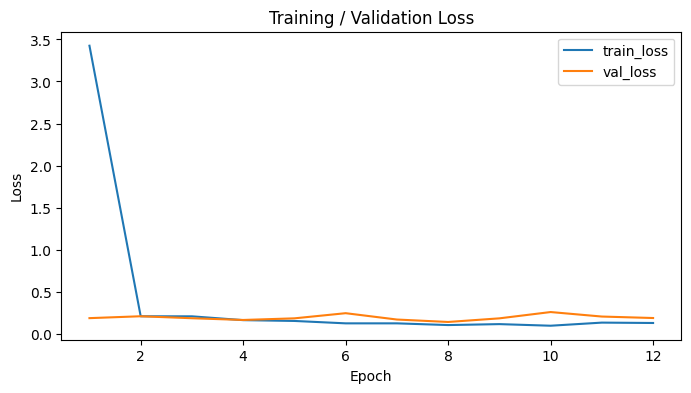

In [11]:
epochs = np.arange(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history['train_loss'], label='train_loss')
plt.plot(epochs, history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.legend()
plt.show()


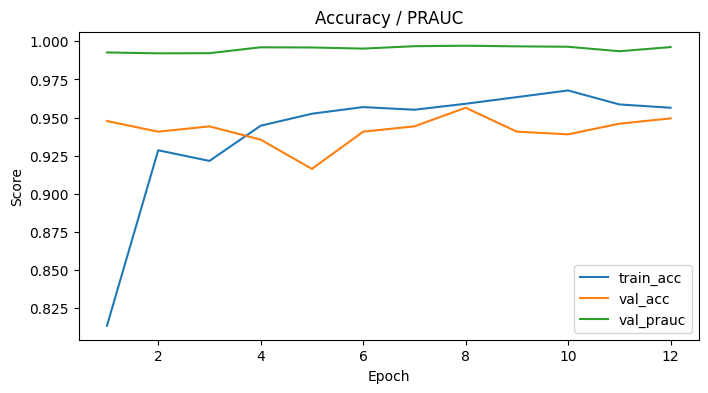

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(epochs, history['train_acc'], label='train_acc')
plt.plot(epochs, history['val_acc'], label='val_acc')
plt.plot(epochs, history['val_prauc'], label='val_prauc')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Accuracy / PRAUC')
plt.legend()
plt.show()


## Résumé final


In [13]:
summary = {
    'train_size': len(train_set),
    'val_size': len(val_set),
    'best_val_prauc': float(best_prauc),
    'last_train_acc': float(history['train_acc'][-1]) if history['train_acc'] else None,
    'last_val_acc': float(history['val_acc'][-1]) if history['val_acc'] else None,
    'checkpoint_path': str(CHECKPOINT_PATH),
}

print(json.dumps(summary, indent=2))


{
  "train_size": 2296,
  "val_size": 574,
  "best_val_prauc": 0.9970970032410369,
  "last_train_acc": 0.9564459930313589,
  "last_val_acc": 0.9494773519163763,
  "checkpoint_path": "/home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification/artifacts/checkpoints/best_smallcnn_baseline.pt"
}


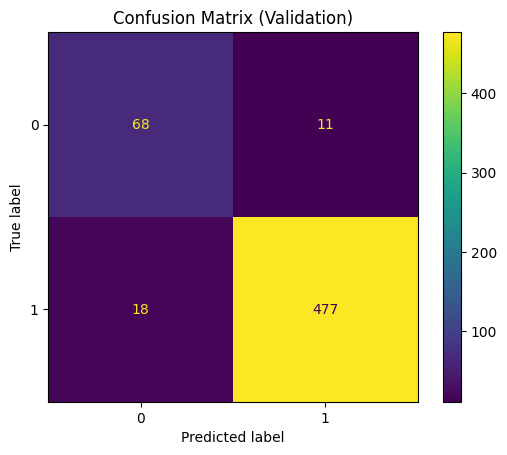


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        79
           1       0.98      0.96      0.97       495

    accuracy                           0.95       574
   macro avg       0.88      0.91      0.90       574
weighted avg       0.95      0.95      0.95       574



In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

y_true = np.array(val_stats["targets"])
y_probs = np.array(val_stats["probs"])

y_pred = (y_probs >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix (Validation)")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

#  Résultats finaux — Modèle SmallCNN

##  Objectif

Évaluer les performances finales du modèle **SmallCNN** pour la classification binaire des images IRM cérébrales (tumeur vs non-tumeur), à partir d’un pipeline méthodologiquement correct :

- Split **train/validation stratifié (80/20)**
- Entraînement avec early stopping
- Sélection du meilleur modèle via **PRAUC**
- Analyse des erreurs via matrice de confusion

---

##  Performances globales

| Métrique              | Valeur |
|----------------------|--------|
| Train Accuracy       | **95.6%** |
| Validation Accuracy  | **94.9%** |
| Validation PRAUC     | **0.997** |

###  Interprétation

- Le modèle atteint une **excellente performance globale**
- La **PRAUC très élevée** indique une très bonne séparation entre les classes
- Les performances train/validation sont proches → **bonne généralisation**

---

##  Analyse des erreurs

###  Matrice de confusion (Validation)

```text
TN = 68
FP = 11
FN = 18
TP = 477